[문제] 캘리포니아 주택 기격 데이터를 사용하여 MSE가 최소가 되는 모델을 파이토치로 구현하는 코드를 작성하시오.

제출형식 : 홍길동_0528_MSE.ipynb

<처리조건>
1. 캘리포니아 주택 기격 데이터는 아래 내용을 참고한다.
from sklearn.datasets import fetch_california_housing

california_data = fetch_california_housing()

2. 모델은 nn.Module 클래스를 상속받아 구현한다.
3. 마지막에 테스트 데이터에 대한 MSE룰 출력한다.
   학습데이터:검증데이터;테스트데이터 = 8:1:1로 한다.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cuda


In [83]:
device = torch.device('cpu')
print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cpu


## 데이터 로드 및 전처리

In [3]:
california_data = fetch_california_housing()
california_data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
print(california_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [88]:
X = pd.DataFrame(california_data.data, columns=california_data.feature_names)
y = pd.DataFrame(california_data.target, columns=california_data.target_names)

In [89]:
X.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22


In [90]:
y.head(2)

,MedHouseVal
0,4.526
1,3.585


In [91]:
mm_sc = MinMaxScaler()
X_scaled = mm_sc.fit_transform(X)

In [92]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [93]:
X_scaled

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

In [94]:
# 8:1:1
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.111, random_state=42)

In [95]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train.values).view(-1,1) # 2차원 구조로 변환(N, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val.values).view(-1,1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test.values).view(-1,1)

In [96]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [97]:
print(f"Train set : {X_train.shape}, Val set: {X_val.shape}, Test set : {X_test.shape}")

Train set : torch.Size([16514, 8]), Val set: torch.Size([2062, 8]), Test set : torch.Size([2064, 8])


## 모델

### minmax
- Test MSE Loss: 0.3369
- 실제값(예시): 0.48, 예측값: 0.68
- Test MAE (오차 평균): 0.3910

In [105]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [106]:
model = Model(input_dim=8)

In [107]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [108]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.6828, Val Loss: 0.6426
epoch [2/100], Train Loss: 0.5014, Val Loss: 0.5649
epoch [3/100], Train Loss: 0.4683, Val Loss: 0.4828
epoch [4/100], Train Loss: 0.4566, Val Loss: 0.4942
epoch [5/100], Train Loss: 0.4450, Val Loss: 0.5216
epoch [6/100], Train Loss: 0.4376, Val Loss: 0.4517
epoch [7/100], Train Loss: 0.4353, Val Loss: 0.5096
epoch [8/100], Train Loss: 0.4351, Val Loss: 0.4427
epoch [9/100], Train Loss: 0.4279, Val Loss: 0.4362
epoch [10/100], Train Loss: 0.4224, Val Loss: 0.4763
epoch [11/100], Train Loss: 0.4238, Val Loss: 0.4557
epoch [12/100], Train Loss: 0.4097, Val Loss: 0.4267
epoch [13/100], Train Loss: 0.4098, Val Loss: 0.4450
epoch [14/100], Train Loss: 0.4093, Val Loss: 0.4100
epoch [15/100], Train Loss: 0.4001, Val Loss: 0.4545
epoch [16/100], Train Loss: 0.4058, Val Loss: 0.4176
epoch [17/100], Train Loss: 0.4034, Val Loss: 0.4170
epoch [18/100], Train Loss: 0.4013, Val Loss: 0.4252
epoch [19/100], Train Loss: 0.3899, Val Loss: 0.3999
ep

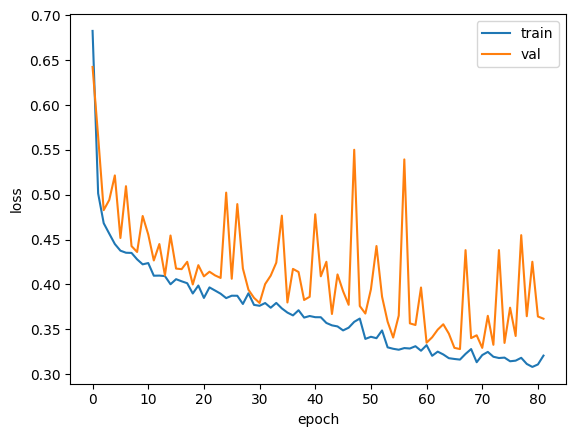

In [109]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [110]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [111]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.3369
실제값(예시): 0.48, 예측값: 0.68
Test MAE (오차 평균): 0.3910


### StandardScaler

#### model1
- Test MSE Loss: 0.3016
- 실제값(예시): 0.48, 예측값: 0.55
- Test MAE (오차 평균): 0.3783

In [118]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [119]:
model = Model(input_dim=8)

In [120]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [121]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.4938, Val Loss: 0.3941
epoch [2/100], Train Loss: 0.3717, Val Loss: 0.3519
epoch [3/100], Train Loss: 0.3672, Val Loss: 0.3838
epoch [4/100], Train Loss: 0.3647, Val Loss: 0.3739
epoch [5/100], Train Loss: 0.3357, Val Loss: 0.3302
epoch [6/100], Train Loss: 0.3236, Val Loss: 0.3459
epoch [7/100], Train Loss: 0.3203, Val Loss: 0.3207
epoch [8/100], Train Loss: 0.3174, Val Loss: 0.3262
epoch [9/100], Train Loss: 0.3148, Val Loss: 0.3670
epoch [10/100], Train Loss: 0.3243, Val Loss: 0.3408
epoch [11/100], Train Loss: 0.3166, Val Loss: 0.3354
epoch [12/100], Train Loss: 0.3215, Val Loss: 0.3429
epoch [13/100], Train Loss: 0.3035, Val Loss: 0.3501
epoch [14/100], Train Loss: 0.2992, Val Loss: 0.3443
epoch [15/100], Train Loss: 0.2960, Val Loss: 0.3240
epoch [16/100], Train Loss: 0.3979, Val Loss: 0.3252
epoch [17/100], Train Loss: 0.3071, Val Loss: 0.3177
epoch [18/100], Train Loss: 0.2955, Val Loss: 0.3314
epoch [19/100], Train Loss: 0.2954, Val Loss: 0.3745
ep

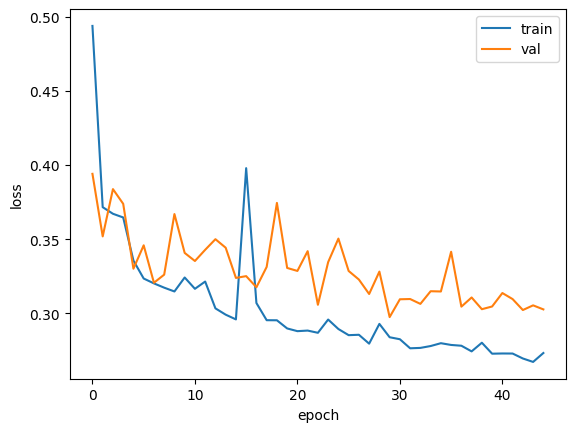

In [122]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [123]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [124]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.3016
실제값(예시): 0.48, 예측값: 0.55
Test MAE (오차 평균): 0.3783


#### model2
- Test MSE Loss: 0.2714
- 실제값(예시): 0.48, 예측값: 0.55
- Test MAE (오차 평균): 0.3570

In [53]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [54]:
model = Model(input_dim=8)
model = model.to(device)

In [55]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [56]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        X_val, y_val = X_val.to(device), y_val.to(device)
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5263, Val Loss: 0.5197
epoch [2/100], Train Loss: 0.3943, Val Loss: 0.3771
epoch [3/100], Train Loss: 0.3490, Val Loss: 0.3540
epoch [4/100], Train Loss: 0.3375, Val Loss: 0.3648
epoch [5/100], Train Loss: 0.3281, Val Loss: 0.3457
epoch [6/100], Train Loss: 0.3137, Val Loss: 0.4263
epoch [7/100], Train Loss: 0.3608, Val Loss: 0.3400
epoch [8/100], Train Loss: 0.3131, Val Loss: 0.3318
epoch [9/100], Train Loss: 0.3052, Val Loss: 0.3174
epoch [10/100], Train Loss: 0.2975, Val Loss: 0.3409
epoch [11/100], Train Loss: 0.2951, Val Loss: 0.3168
epoch [12/100], Train Loss: 0.2953, Val Loss: 0.3089
epoch [13/100], Train Loss: 0.2880, Val Loss: 0.3167
epoch [14/100], Train Loss: 0.2860, Val Loss: 0.3198
epoch [15/100], Train Loss: 0.2892, Val Loss: 0.3481
epoch [16/100], Train Loss: 0.2811, Val Loss: 0.3473
epoch [17/100], Train Loss: 0.2809, Val Loss: 0.3095
epoch [18/100], Train Loss: 0.2741, Val Loss: 0.3060
epoch [19/100], Train Loss: 0.2737, Val Loss: 0.3062
ep

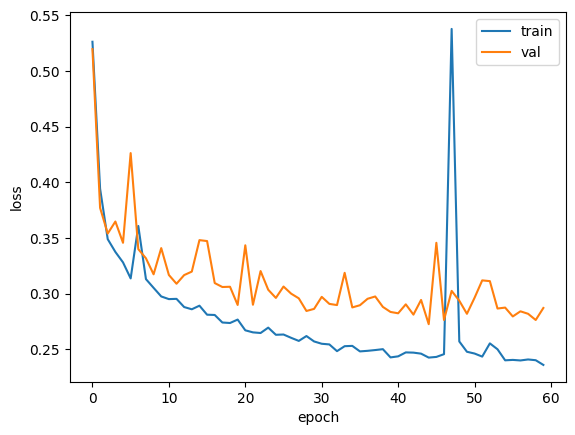

In [57]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [58]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [59]:
model.eval()
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2714
실제값(예시): 0.48, 예측값: 0.55
Test MAE (오차 평균): 0.3570


#### model3
- Test MSE Loss: 0.2838
- 실제값(예시): 0.48, 예측값: 0.49
- Test MAE (오차 평균): 0.3562

In [132]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.model(x)

In [133]:
model = Model(input_dim=8)

In [134]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [135]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.4770, Val Loss: 0.3938
epoch [2/100], Train Loss: 0.3713, Val Loss: 0.3746
epoch [3/100], Train Loss: 0.3486, Val Loss: 0.3536
epoch [4/100], Train Loss: 0.3285, Val Loss: 0.3457
epoch [5/100], Train Loss: 0.3187, Val Loss: 0.3197
epoch [6/100], Train Loss: 0.3183, Val Loss: 0.5468
epoch [7/100], Train Loss: 0.4358, Val Loss: 0.3259
epoch [8/100], Train Loss: 0.3029, Val Loss: 0.3233
epoch [9/100], Train Loss: 0.2943, Val Loss: 0.3056
epoch [10/100], Train Loss: 0.2904, Val Loss: 0.3115
epoch [11/100], Train Loss: 0.2891, Val Loss: 0.3501
epoch [12/100], Train Loss: 0.2861, Val Loss: 0.3039
epoch [13/100], Train Loss: 0.2780, Val Loss: 0.3081
epoch [14/100], Train Loss: 0.2793, Val Loss: 0.3006
epoch [15/100], Train Loss: 0.2778, Val Loss: 0.3024
epoch [16/100], Train Loss: 0.2737, Val Loss: 0.2939
epoch [17/100], Train Loss: 0.2738, Val Loss: 0.3037
epoch [18/100], Train Loss: 0.2717, Val Loss: 0.2912
epoch [19/100], Train Loss: 0.2697, Val Loss: 0.2941
ep

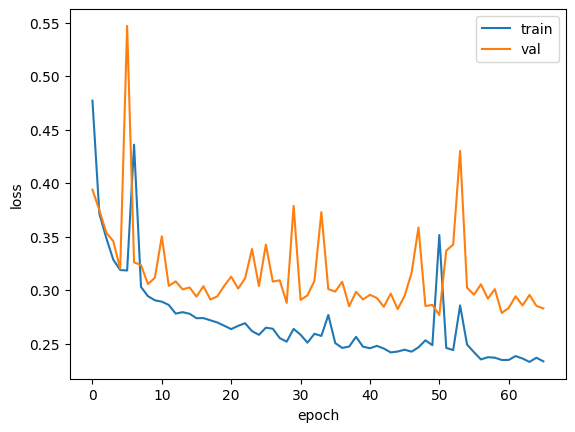

In [136]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [137]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [138]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2838
실제값(예시): 0.48, 예측값: 0.49
Test MAE (오차 평균): 0.3562


#### model4
- Test MSE Loss: 0.2810
- 실제값(예시): 0.48, 예측값: 0.51
- Test MAE (오차 평균): 0.3543

In [139]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [140]:
model = Model(input_dim=8)

In [141]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [142]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5472, Val Loss: 0.4652
epoch [2/100], Train Loss: 0.3875, Val Loss: 0.3615
epoch [3/100], Train Loss: 0.3571, Val Loss: 0.3483
epoch [4/100], Train Loss: 0.3486, Val Loss: 0.3590
epoch [5/100], Train Loss: 0.3245, Val Loss: 0.3927
epoch [6/100], Train Loss: 0.3228, Val Loss: 0.3399
epoch [7/100], Train Loss: 0.3179, Val Loss: 0.4208
epoch [8/100], Train Loss: 0.3116, Val Loss: 0.3305
epoch [9/100], Train Loss: 0.3015, Val Loss: 0.3106
epoch [10/100], Train Loss: 0.3083, Val Loss: 0.3366
epoch [11/100], Train Loss: 0.2998, Val Loss: 0.3327
epoch [12/100], Train Loss: 0.2935, Val Loss: 0.3262
epoch [13/100], Train Loss: 0.2912, Val Loss: 0.3266
epoch [14/100], Train Loss: 0.2897, Val Loss: 0.3111
epoch [15/100], Train Loss: 0.2905, Val Loss: 0.3360
epoch [16/100], Train Loss: 0.2847, Val Loss: 0.3029
epoch [17/100], Train Loss: 0.2786, Val Loss: 0.3039
epoch [18/100], Train Loss: 0.2852, Val Loss: 0.3395
epoch [19/100], Train Loss: 0.2792, Val Loss: 0.3111
ep

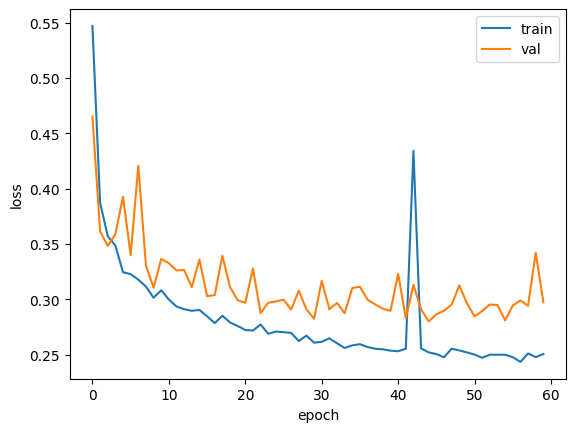

In [143]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [144]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [145]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2810
실제값(예시): 0.48, 예측값: 0.51
Test MAE (오차 평균): 0.3543


#### model5
- Test MSE Loss: 0.2903
- 실제값(예시): 0.48, 예측값: 0.54
- Test MAE (오차 평균): 0.3647

In [146]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.model(x)

In [147]:
model = Model(input_dim=8)

In [148]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [149]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 1.0839, Val Loss: 0.3794
epoch [2/100], Train Loss: 0.4499, Val Loss: 0.3738
epoch [3/100], Train Loss: 0.3455, Val Loss: 0.3634
epoch [4/100], Train Loss: 0.3357, Val Loss: 0.3498
epoch [5/100], Train Loss: 0.3306, Val Loss: 0.3797
epoch [6/100], Train Loss: 0.3177, Val Loss: 0.3451
epoch [7/100], Train Loss: 0.3219, Val Loss: 0.3257
epoch [8/100], Train Loss: 0.3067, Val Loss: 0.3175
epoch [9/100], Train Loss: 0.2979, Val Loss: 0.3332
epoch [10/100], Train Loss: 0.2939, Val Loss: 0.3170
epoch [11/100], Train Loss: 0.2938, Val Loss: 0.2985
epoch [12/100], Train Loss: 0.2865, Val Loss: 0.3154
epoch [13/100], Train Loss: 0.2842, Val Loss: 0.2982
epoch [14/100], Train Loss: 0.2822, Val Loss: 0.3383
epoch [15/100], Train Loss: 0.2807, Val Loss: 0.3483
epoch [16/100], Train Loss: 0.2827, Val Loss: 0.3090
epoch [17/100], Train Loss: 0.2815, Val Loss: 0.2940
epoch [18/100], Train Loss: 0.2706, Val Loss: 0.2846
epoch [19/100], Train Loss: 0.2753, Val Loss: 0.3072
ep

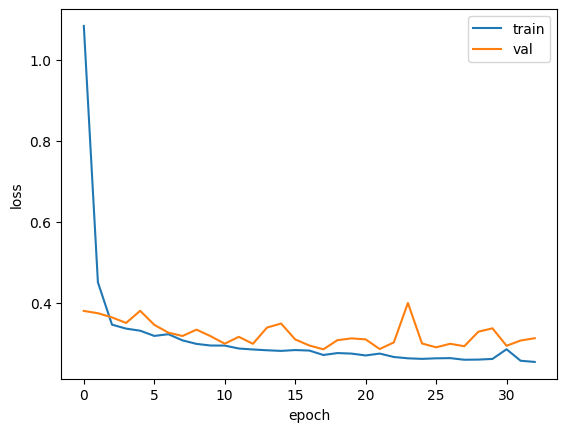

In [150]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [151]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [152]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2903
실제값(예시): 0.48, 예측값: 0.54
Test MAE (오차 평균): 0.3647


#### model6
- Test MSE Loss: 0.2895
- 실제값(예시): 0.48, 예측값: 0.45
- Test MAE (오차 평균): 0.3633

In [46]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [47]:
model = Model(input_dim=8)
model = model.to(device)

In [48]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [49]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        X_val, y_val = X_val.to(device), y_val.to(device)
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5105, Val Loss: 0.4035
epoch [2/100], Train Loss: 0.4764, Val Loss: 0.6779
epoch [3/100], Train Loss: 0.4501, Val Loss: 0.3468
epoch [4/100], Train Loss: 0.3694, Val Loss: 0.3663
epoch [5/100], Train Loss: 0.3404, Val Loss: 0.3507
epoch [6/100], Train Loss: 0.3576, Val Loss: 0.3318
epoch [7/100], Train Loss: 0.3153, Val Loss: 0.3323
epoch [8/100], Train Loss: 0.3134, Val Loss: 0.3214
epoch [9/100], Train Loss: 0.3043, Val Loss: 0.3555
epoch [10/100], Train Loss: 0.2968, Val Loss: 0.3127
epoch [11/100], Train Loss: 0.2942, Val Loss: 0.3168
epoch [12/100], Train Loss: 0.2906, Val Loss: 0.3111
epoch [13/100], Train Loss: 0.2879, Val Loss: 0.3304
epoch [14/100], Train Loss: 0.2852, Val Loss: 0.3179
epoch [15/100], Train Loss: 0.2829, Val Loss: 0.3592
epoch [16/100], Train Loss: 0.2941, Val Loss: 0.3074
epoch [17/100], Train Loss: 0.2797, Val Loss: 0.3214
epoch [18/100], Train Loss: 0.2758, Val Loss: 0.2836
epoch [19/100], Train Loss: 0.2726, Val Loss: 0.3092
ep

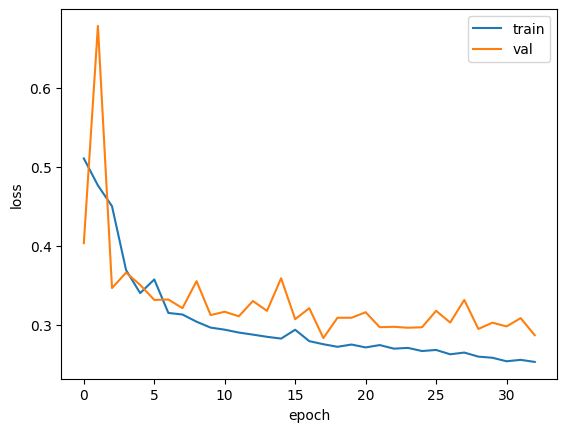

In [50]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [51]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [52]:
model.eval()
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2895
실제값(예시): 0.48, 예측값: 0.45
Test MAE (오차 평균): 0.3633


#### model7
- Test MSE Loss: 0.2946
- 실제값(예시): 0.48, 예측값: 0.53
- Test MAE (오차 평균): 0.3644

In [67]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [68]:
model = Model(input_dim=8)
model = model.to(device)

In [69]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [70]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        X_val, y_val = X_val.to(device), y_val.to(device)
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5421, Val Loss: 0.9822
epoch [2/100], Train Loss: 0.4337, Val Loss: 0.3811
epoch [3/100], Train Loss: 0.3512, Val Loss: 0.3651
epoch [4/100], Train Loss: 0.3591, Val Loss: 0.3784
epoch [5/100], Train Loss: 0.3294, Val Loss: 0.3402
epoch [6/100], Train Loss: 0.3267, Val Loss: 0.3415
epoch [7/100], Train Loss: 0.3084, Val Loss: 0.3363
epoch [8/100], Train Loss: 0.3098, Val Loss: 0.3197
epoch [9/100], Train Loss: 0.3048, Val Loss: 0.4264
epoch [10/100], Train Loss: 0.2991, Val Loss: 0.3034
epoch [11/100], Train Loss: 0.2931, Val Loss: 0.4198
epoch [12/100], Train Loss: 0.2882, Val Loss: 0.3286
epoch [13/100], Train Loss: 0.2880, Val Loss: 0.2844
epoch [14/100], Train Loss: 0.2822, Val Loss: 0.3339
epoch [15/100], Train Loss: 0.2773, Val Loss: 0.2960
epoch [16/100], Train Loss: 0.2748, Val Loss: 0.2911
epoch [17/100], Train Loss: 0.2836, Val Loss: 0.3445
epoch [18/100], Train Loss: 0.2769, Val Loss: 0.3218
epoch [19/100], Train Loss: 0.2716, Val Loss: 0.2899
ep

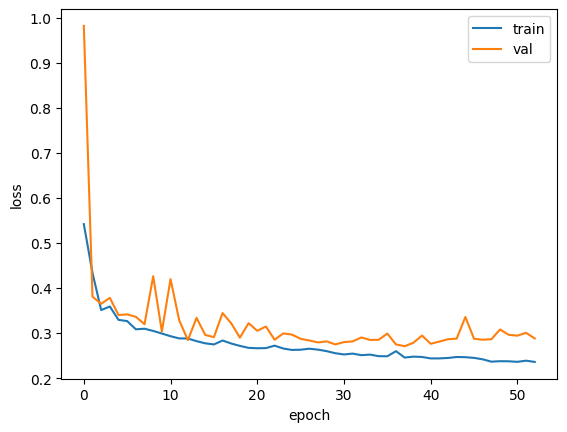

In [71]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [72]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [73]:
model.eval()
with torch.no_grad():
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2946
실제값(예시): 0.48, 예측값: 0.53
Test MAE (오차 평균): 0.3644


#### model8
- Test MSE Loss: 0.2909
- 실제값(예시): 0.48, 예측값: 0.54
- Test MAE (오차 평균): 0.3668

In [105]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.model(x)

In [106]:
model = Model(input_dim=8)

In [107]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [108]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.4904, Val Loss: 0.4085
epoch [2/100], Train Loss: 0.4334, Val Loss: 0.5789
epoch [3/100], Train Loss: 0.3590, Val Loss: 0.3856
epoch [4/100], Train Loss: 0.3692, Val Loss: 0.3412
epoch [5/100], Train Loss: 0.3301, Val Loss: 0.3457
epoch [6/100], Train Loss: 0.3200, Val Loss: 0.3285
epoch [7/100], Train Loss: 0.3120, Val Loss: 0.3257
epoch [8/100], Train Loss: 0.3125, Val Loss: 0.3194
epoch [9/100], Train Loss: 0.3029, Val Loss: 0.3415
epoch [10/100], Train Loss: 0.3064, Val Loss: 0.3631
epoch [11/100], Train Loss: 0.3047, Val Loss: 0.3763
epoch [12/100], Train Loss: 0.2901, Val Loss: 0.2997
epoch [13/100], Train Loss: 0.2934, Val Loss: 0.2986
epoch [14/100], Train Loss: 0.2890, Val Loss: 0.3240
epoch [15/100], Train Loss: 0.2810, Val Loss: 0.3108
epoch [16/100], Train Loss: 0.2768, Val Loss: 0.2917
epoch [17/100], Train Loss: 0.2741, Val Loss: 0.3028
epoch [18/100], Train Loss: 0.2734, Val Loss: 0.2986
epoch [19/100], Train Loss: 0.2695, Val Loss: 0.3096
ep

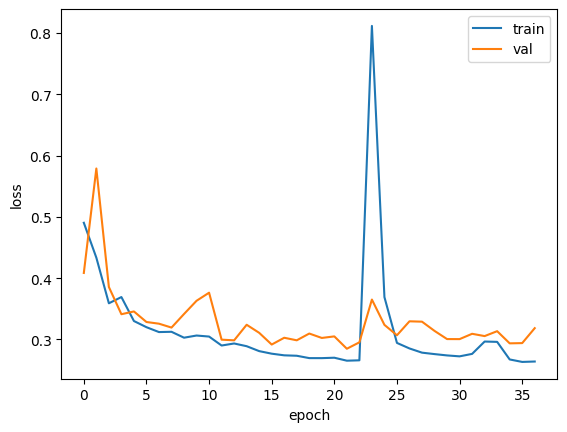

In [109]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [110]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [111]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2909
실제값(예시): 0.48, 예측값: 0.54
Test MAE (오차 평균): 0.3668


#### model9
- Test MSE Loss: 0.2893
- 실제값(예시): 0.48, 예측값: 0.64
- Test MAE (오차 평균): 0.3621

In [112]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )
    def forward(self, x):
        return self.model(x)

In [113]:
model = Model(input_dim=8)

In [114]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [115]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5464, Val Loss: 0.4034
epoch [2/100], Train Loss: 0.3790, Val Loss: 0.3749
epoch [3/100], Train Loss: 0.3521, Val Loss: 0.4204
epoch [4/100], Train Loss: 0.3529, Val Loss: 0.5016
epoch [5/100], Train Loss: 0.3444, Val Loss: 0.4013
epoch [6/100], Train Loss: 0.3293, Val Loss: 0.4840
epoch [7/100], Train Loss: 0.3233, Val Loss: 0.3234
epoch [8/100], Train Loss: 0.3211, Val Loss: 0.3237
epoch [9/100], Train Loss: 0.3035, Val Loss: 0.3152
epoch [10/100], Train Loss: 0.2959, Val Loss: 0.3147
epoch [11/100], Train Loss: 0.2920, Val Loss: 0.3534
epoch [12/100], Train Loss: 0.2948, Val Loss: 0.3216
epoch [13/100], Train Loss: 0.2910, Val Loss: 0.3279
epoch [14/100], Train Loss: 0.2849, Val Loss: 0.2988
epoch [15/100], Train Loss: 0.2843, Val Loss: 0.3387
epoch [16/100], Train Loss: 0.2824, Val Loss: 0.3129
epoch [17/100], Train Loss: 0.2837, Val Loss: 0.3595
epoch [18/100], Train Loss: 0.2744, Val Loss: 0.2948
epoch [19/100], Train Loss: 0.2750, Val Loss: 0.3059
ep

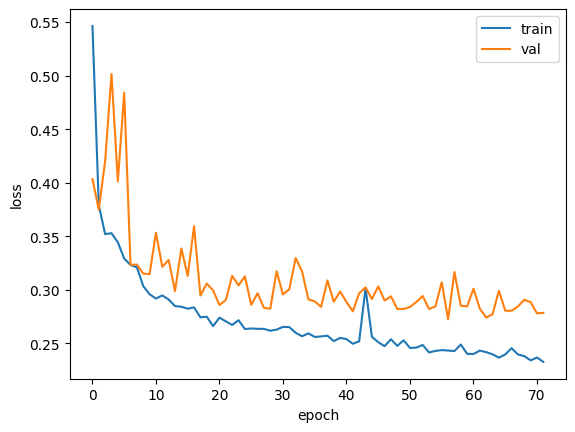

In [116]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [117]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [118]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2893
실제값(예시): 0.48, 예측값: 0.64
Test MAE (오차 평균): 0.3621


#### model10
- Test MSE Loss: 0.2803
- 실제값(예시): 0.48, 예측값: 0.61
- Test MAE (오차 평균): 0.3561

In [119]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [120]:
model = Model(input_dim=8)

In [121]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [122]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 15 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

    train_loss = train_loss / len(train_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss.item())

    if best_loss == -1 or val_loss.item() < best_loss:
        best_loss = val_loss.item()
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'california_best_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

epoch [1/100], Train Loss: 0.5077, Val Loss: 0.4219
epoch [2/100], Train Loss: 0.3710, Val Loss: 0.3708
epoch [3/100], Train Loss: 0.3722, Val Loss: 0.4540
epoch [4/100], Train Loss: 0.3498, Val Loss: 0.3888
epoch [5/100], Train Loss: 0.3306, Val Loss: 0.3481
epoch [6/100], Train Loss: 0.3258, Val Loss: 0.3456
epoch [7/100], Train Loss: 0.3132, Val Loss: 0.3402
epoch [8/100], Train Loss: 0.3076, Val Loss: 0.3393
epoch [9/100], Train Loss: 0.3025, Val Loss: 0.3345
epoch [10/100], Train Loss: 0.3081, Val Loss: 0.3075
epoch [11/100], Train Loss: 0.2985, Val Loss: 0.3268
epoch [12/100], Train Loss: 0.2958, Val Loss: 0.3298
epoch [13/100], Train Loss: 0.2933, Val Loss: 0.3419
epoch [14/100], Train Loss: 0.2872, Val Loss: 0.2912
epoch [15/100], Train Loss: 0.2849, Val Loss: 0.3101
epoch [16/100], Train Loss: 0.2858, Val Loss: 0.3161
epoch [17/100], Train Loss: 0.2786, Val Loss: 0.3199
epoch [18/100], Train Loss: 0.2798, Val Loss: 0.2922
epoch [19/100], Train Loss: 0.2739, Val Loss: 0.3048
ep

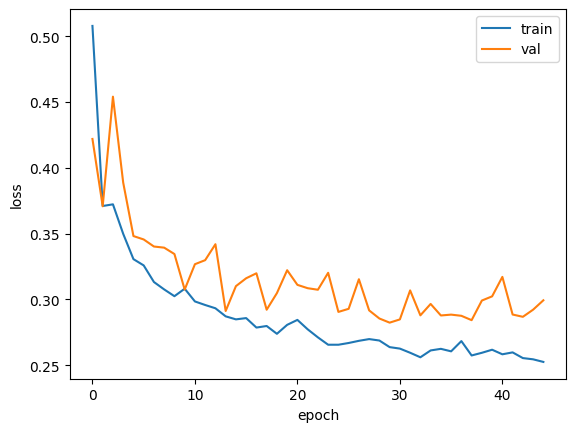

In [123]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [124]:
model.load_state_dict(torch.load('california_best_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [125]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2803
실제값(예시): 0.48, 예측값: 0.61
Test MAE (오차 평균): 0.3561


#### model11
- Test MSE Loss: 0.2966
- 실제값(예시): 0.48, 예측값: 0.57
- Test MAE (오차 평균): 0.3587

In [126]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.model(x)

In [127]:
model = Model(input_dim=8)

In [128]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [129]:
epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    
    print(f"epoch [{epoch+1}/{epochs}], Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss.item():.4f}")

epoch [1/100], Train Loss: 0.4988, Val Loss: 0.4009
epoch [2/100], Train Loss: 0.3676, Val Loss: 0.4874
epoch [3/100], Train Loss: 0.4024, Val Loss: 0.3676
epoch [4/100], Train Loss: 0.3496, Val Loss: 0.3693
epoch [5/100], Train Loss: 0.3291, Val Loss: 0.3959
epoch [6/100], Train Loss: 0.3305, Val Loss: 0.3674
epoch [7/100], Train Loss: 0.3228, Val Loss: 0.3413
epoch [8/100], Train Loss: 0.3192, Val Loss: 0.3628
epoch [9/100], Train Loss: 0.3142, Val Loss: 0.3256
epoch [10/100], Train Loss: 0.3080, Val Loss: 0.3265
epoch [11/100], Train Loss: 0.3056, Val Loss: 0.3390
epoch [12/100], Train Loss: 0.2996, Val Loss: 0.3326
epoch [13/100], Train Loss: 0.2989, Val Loss: 0.3293
epoch [14/100], Train Loss: 0.2953, Val Loss: 0.3259
epoch [15/100], Train Loss: 0.2945, Val Loss: 0.3238
epoch [16/100], Train Loss: 0.2930, Val Loss: 0.3056
epoch [17/100], Train Loss: 0.2885, Val Loss: 0.3118
epoch [18/100], Train Loss: 0.2798, Val Loss: 0.3018
epoch [19/100], Train Loss: 0.2755, Val Loss: 0.3038
ep

In [131]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f"Test MSE Loss: {test_loss.item():.4f}") # MSE 출력
    print(f"실제값(예시): {y_test[0].item():.2f}, 예측값: {test_pred[0].item():.2f}")

mae = torch.mean(torch.abs(test_pred - y_test)) # MAE 계산
print(f"Test MAE (오차 평균): {mae.item():.4f}")

Test MSE Loss: 0.2966
실제값(예시): 0.48, 예측값: 0.57
Test MAE (오차 평균): 0.3587
